# Coin Detection System - Computer Vision Project
---

## Overview
This notebook detects and classifies coins in images using traditional computer vision techniques:
- **Circular Hough Transform** for circle detection
- **Size and Color analysis** for classification
- **No currency assumptions** - works for any coins worldwide

## Algorithm Pipeline
1. Load and preprocess image (grayscale + blur)
2. Detect circular shapes using Hough Transform
3. Extract features (radius, color) for each coin
4. Classify by size category and color
5. Group similar coins together
6. Visualize and summarize results

## Team Members
| Name                | ID      |
|---------------------|---------|
| Ahmed Hazem         | 22P0226 |
| Karim Hatem         | 22P0153 |
| Youssef Mostafa     | 22P0047 |
| Mostafa Foaad       | 22P0077 |
| AbdElRahman Mostafa | 22P0053 |

## Section 0 : Importing Libraries

In [254]:
import cv2
import os
import numpy as np
import math
from collections import Counter
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")
print(f"OpenCV version: {cv2.__version__}")

Libraries loaded successfully!
OpenCV version: 4.13.0


## Section 1 : Color Classification Functions
Defines coin colors (Silver, Gold, Copper, etc.)

Classify color based on HSV values

Parameters: hsv_color : tuple (Hue, Saturation, Value) values

Returns: (str) Color category name

In [255]:
# Section 1
def get_color_name(hsv_color):
    h, s, v = hsv_color

    # Very dark/black coins (some tokens, old coins)
    if v < 40:
        return "Dark/Black"

    # Silver/White coins (most modern coins: US quarters, dimes, Euro cents)
    if v > 180 and s < 40:
        return "Silver"

    # Gold/Brass coins (US dollars, some Euro coins, Arabic coins)
    if 15 <= h <= 35 and s > 40 and v > 100:
        return "Gold/Brass"

    # Copper/Bronze coins (US pennies, UK pennies, some Euro cents)
    if (h <= 15 or h >= 160) and s > 50 and v > 70:
        return "Copper/Bronze"

    # Nickel/Silver-gray tones (US nickels, some Euro coins)
    if 20 <= h <= 80 and s < 50 and v > 100:
        return "Nickel/Silver"

    # Yellowish coins (some commemorative coins, older gold-colored)
    if 25 <= h <= 45 and s > 40 and v > 120:
        return "Yellow/Gold"

    # Reddish-brown coins (very old copper coins, some tokens)
    if h <= 10 and s > 60 and 50 < v < 120:
        return "Reddish-Brown"

    # Gray coins (worn silver coins, some base metals)
    if s < 30 and 80 < v < 180:
        return "Gray"

    # Default for unusual coins
    return "Colored"

# Test the color function
test_colors = [
    (30, 100, 200),  # Should be Gold/Brass
    (10, 80, 150),   # Should be Copper/Bronze
    (60, 20, 220),   # Should be Silver
]

for hsv in test_colors:
    print(f"HSV {hsv} -> {get_color_name(hsv)}")

HSV (30, 100, 200) -> Gold/Brass
HSV (10, 80, 150) -> Copper/Bronze
HSV (60, 20, 220) -> Silver


## Section 2 : Mathematical Dynamic Sizing

This section implements a scale-independent classification system. Instead of using hard-coded pixel values, it calculates size boundaries dynamically based on the specific range of coins present in the current image.

### Logic: Linear Range Division
The algorithm identifies the **minimum** and **maximum** radii in the detection set and divides the total spread into three equal mathematical intervals:
1. **Small**: The bottom 33% of the size range.
2. **Medium**: The middle 33% of the size range.
3. **Large**: The top 33% of the size range.

### Functions

| Function | Purpose |
| :--- | :--- |
| `get_dynamic_thresholds` | Scans the detected radii to calculate image-specific `small_limit` and `medium_limit`. |
| `get_size_category` | Assigns a label ("Small", "Medium", "Large") based on the calculated limits. |

In [256]:
# Section 2 - Mathematical Dynamic Sizing
def get_dynamic_thresholds(coins_data):
    """Calculates boundaries based on the distribution of sizes in the current image."""
    if not coins_data:
        return None

    # We use radius for thresholds
    radii = [c['radius'] for c in coins_data]
    r_min, r_max = min(radii), max(radii)

    # Divide the spread into 3 equal mathematical intervals
    step = (r_max - r_min) / 3
    return {
        "small_limit": r_min + step,
        "medium_limit": r_min + 2 * step
    }

def get_size_category(radius, thresholds):
    """Assigns category based on the image's dynamic math."""
    if not thresholds:
        return "Unknown"
    if radius < thresholds["small_limit"]:
        return "Small"
    elif radius < thresholds["medium_limit"]:
        return "Medium"
    else:
        return "Large"

## Section 3 : Replicated Padding & Hardened Deduplication Pipeline

This section enhances detection accuracy by solving two common computer vision problems: "edge-cutting" (where coins near the border are missed) and "ghosting" (where double circles appear on a single coin).

### The Technique: Border Replication
Standard padding often adds black or white pixels, creating a harsh "artificial edge" that confuses circle detection algorithms. This system uses **BORDER_REPLICATE**, which stretches the edge pixels outward smoothly. This eliminates fake gradients and allows the Hough Transform to "see" coins that are partially outside the original frame.



### Hardened Deduplication Logic
To ensure every coin is counted exactly once, the system uses a strict geometric filter. It compares every new detection against existing ones using two criteria:
1. **Center Distance**: If a new center is inside an existing coin's radius, it is rejected as a duplicate.
2. **Boundary Shielding**: If the overlap exceeds a critical percentage, it is flagged as a "ghost" detection and discarded.

### Multi-Pass Sweep Strategy
The detection runs in three increasingly sensitive layers:

| Pass | Search Type | Goal |
| :--- | :--- | :--- |
| **Pass 1** | **Dominant/Macro** | Detects large, clear, and zoomed-in coins with high confidence. |
| **Pass 2** | **Standard/Cluster** | Finds medium coins and those packed tightly together. |
| **Pass 3** | **Boundary Recovery** | Rescues faint or partially occluded coins missed by previous passes. |

### Key Validation Functions
* **`standardize_image_with_padding`**: Handles the resolution normalization and the seamless border extension.
* **`is_duplicate`**: Acts as the "gatekeeper" to ensure no overlapping or redundant circles enter the final count.
* **`detect_coins`**: Coordinates the 3-pass search and maps the "padded coordinates" back to the "original image space."

In [257]:
# Section 3 - Replicated Padding & Hardened Deduplication Pipeline
def standardize_image_with_padding(image, target_width=800, padding_ratio=0.15):
    """
    Standardizes image width and adds border padding using BORDER_REPLICATE.
    Replicating the border stretches outer pixels smoothly, producing zero artificial edge gradients.
    """
    h, w = image.shape[:2]
    scale = target_width / w
    target_height = int(h * scale)
    inter = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
    std_img = cv2.resize(image, (target_width, target_height), interpolation=inter)
    
    pad_val = int(target_width * padding_ratio)
    padded_img = cv2.copyMakeBorder(
        std_img, pad_val, pad_val, pad_val, pad_val,
        cv2.BORDER_REPLICATE
    )
    
    return padded_img, pad_val, std_img.shape[1], std_img.shape[0]

def is_duplicate(new_circle, existing_circles):
    """Strict geometric filter to eliminate double detections and excess structural overlap."""
    x1, y1, r1 = new_circle
    for (x2, y2, r2) in existing_circles:
        dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        if dist < min(r1, r2) * 0.8:  # Catches direct double detections and inner rims
            return True
        if dist < (r1 + r2) * 0.45:   # Shields against stray ghost boundaries near real coins
            return True
    return False

def detect_coins(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, None

    # 1. Standardize canvas and apply seamless replicated padding
    padded_img, padding, unpadded_w, unpadded_h = standardize_image_with_padding(img, target_width=800)
    gray = cv2.cvtColor(padded_img, cv2.COLOR_BGR2GRAY)

    # 2. Strong median smoothing dissolves internal table textures
    blurred = cv2.medianBlur(gray, 13)
    blurred = cv2.GaussianBlur(blurred, (5, 5), 0)

    valid_circles = []

    # --- PASS 1: Dominant & Macro Coin Search ---
    circles_p1 = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.0, minDist=30,
        param1=110, param2=34, minRadius=15, maxRadius=180
    )
    if circles_p1 is not None:
        for c in np.round(circles_p1[0, :]).astype("int"):
            mapped_circle = [c[0] - padding, c[1] - padding, c[2]]
            if not is_duplicate(mapped_circle, valid_circles):
                valid_circles.append(mapped_circle)

    # --- PASS 2: Standard & Tight Cluster Search ---
    circles_p2 = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.0, minDist=20,
        param1=90, param2=26, minRadius=12, maxRadius=100
    )
    if circles_p2 is not None:
        for c in np.round(circles_p2[0, :]).astype("int"):
            mapped_circle = [c[0] - padding, c[1] - padding, c[2]]
            if not is_duplicate(mapped_circle, valid_circles):
                valid_circles.append(mapped_circle)

    # --- PASS 3: Deep Occlusion & Boundary Recovery Sweep ---
    circles_p3 = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.0, minDist=15,
        param1=80, param2=21, minRadius=12, maxRadius=80
    )
    if circles_p3 is not None:
        for c in np.round(circles_p3[0, :]).astype("int"):
            mapped_circle = [c[0] - padding, c[1] - padding, c[2]]
            
            # Safety lock: Ensure the center of the detection is reasonably on or near the actual canvas
            if -c[2] <= mapped_circle[0] <= unpadded_w + c[2] and -c[2] <= mapped_circle[1] <= unpadded_h + c[2]:
                if not is_duplicate(mapped_circle, valid_circles):
                    valid_circles.append(mapped_circle)

    # 3. Extract the unpadded standardized view to pass forward
    std_unpadded_img = padded_img[padding : padding + unpadded_h, padding : padding + unpadded_w]
    
    print(f"Detected {len(valid_circles)} coins in {os.path.basename(image_path)}")
    return std_unpadded_img, np.array(valid_circles) if valid_circles else None

## Section 4 : Feature Extraction

Extracts size and color features from each detected coin.

Parameters:
- original_image : numpy.ndarray (BGR image)
- circles : numpy.ndarray (detected circles)

Returns: list of dictionaries containing coin features (id, center, radius, diameter, color, size, etc.)

In [258]:
# Section 4 - Enhanced Feature Extraction
import math

def extract_coin_features(original_image, circles, thresholds):
    coin_features = []

    for i, (x, y, r) in enumerate(circles):
        # 1. Create a precise mask for the coin
        mask = np.zeros(original_image.shape[:2], dtype=np.uint8)
        cv2.circle(mask, (int(x), int(y)), int(r), 255, -1)

        # 2. Calculate color in HSV space
        mean_bgr = cv2.mean(original_image, mask=mask)[:3]
        mean_bgr_uint8 = np.uint8([[mean_bgr]])
        mean_hsv = cv2.cvtColor(mean_bgr_uint8, cv2.COLOR_BGR2HSV)[0][0]

        # 3. Build the feature dictionary with all expected keys
        coin_features.append({
            'id': i + 1,
            'center': (int(x), int(y)),
            'radius': int(r),
            'diameter_pixels': int(r * 2), # Required for print_summary
            'area_pixels': math.pi * (r ** 2),
            'color': get_color_name(mean_hsv),
            'size': get_size_category(r, thresholds), # Dynamic classification
            'bgr': mean_bgr,
            'hsv': mean_hsv
        })

    return coin_features

## Section 5 : Coin Grouping

Groups coins that share the same size category AND color.

Parameters: coins : list (coin features from Section 5)

Returns: list of groups with group ID, count, size, color, and average measurements

In [259]:
# Section 5 - Dynamic Grouping with Statistics
def group_similar_coins(coins):
    groups_dict = {}

    for coin in coins:
        # Group by the unique combination of Color and Dynamic Size
        group_key = f"{coin['color']}_{coin['size']}"

        if group_key not in groups_dict:
            groups_dict[group_key] = {
                'id': len(groups_dict) + 1,
                'count': 0,
                'coins': [],
                'color': coin['color'],
                'size': coin['size']
            }

        groups_dict[group_key]['count'] += 1
        groups_dict[group_key]['coins'].append(coin)

    # Calculate statistical averages for each group
    final_groups = []
    for key in groups_dict:
        group = groups_dict[key]
        group['avg_radius'] = np.mean([c['radius'] for c in group['coins']])
        group['avg_diameter'] = np.mean([c['diameter_pixels'] for c in group['coins']])
        final_groups.append(group)

    # Sort groups by coin count (most frequent first)
    final_groups.sort(key=lambda x: x['count'], reverse=True)
    return final_groups

## Section 6 : Image Annotation

Draws results on the image. Circle colors are chosen from realistic metallic/coin colors (no pink, magenta, cyan, etc.)

Parameters:
- image : numpy.ndarray (image to annotate)
- coins : list (coin features)
- groups : list (coin groups)

Returns: annotated image

In [260]:
# Section 6
def annotate_image(image, coins, groups):
    # Realistic colors that might appear on coins or currency
    group_colors = [
        (192, 192, 192),  # Silver
        (218, 165, 32),   # Goldenrod
        (205, 127, 50),   # Copper
        (169, 169, 169),  # Dark Gray
        (255, 215, 0),    # Gold
        (210, 105, 30),   # Bronze
        (128, 128, 128),  # Gray
        (238, 232, 170),  # Pale Goldenrod
        (184, 115, 51),   # Peru (brownish-gold)
        (192, 192, 192),  # Light Silver
    ]

    group_color_map = {}
    for i, group in enumerate(groups):
        group_color_map[group['id']] = group_colors[i % len(group_colors)]

    for coin in coins:
        x, y = coin['center']
        r = coin['radius']

        group_id = None
        for group in groups:
            if coin in group['coins']:
                group_id = group['id']
                break

        if group_id:
            color = group_color_map[group_id]

            cv2.circle(image, (x, y), r, color, 4)
            cv2.circle(image, (x, y), 3, color, -1)

            label = f"G{group_id}: {coin['color']}, {coin['size']}"
            text_x, text_y = x - r, y - r - 10

            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(image, (text_x - 5, text_y - text_h - 5),
                         (text_x + text_w + 5, text_y + 5), (0, 0, 0), -1)
            cv2.rectangle(image, (text_x - 5, text_y - text_h - 5),
                         (text_x + text_w + 5, text_y + 5), color, 2)
            cv2.putText(image, label, (text_x, text_y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    return image

## Section 7 : Results Summary

Prints formatted summary to console and creates statistics image.

Parameters: coins, groups (from previous sections)

Returns: None (prints to console and saves image)

In [261]:
# Section 7
def print_summary(coins, groups):
    print("\n" + "="*60)
    print("COIN DETECTION & CLASSIFICATION SUMMARY")
    print("="*60)
    print(f"\n📊 TOTAL: {len(coins)} coins detected\n")

    print("📋 CLASSIFICATION BY GROUPS:")
    print("-"*60)
    for group in groups:
        print(f"\n GROUP {group['id']}: {group['count']} coins")
        print(f"      Size: {group['size']}")
        print(f"      Color: {group['color']}")
        print(f"      Avg Diameter: {group['avg_diameter']:.1f} pixels")
        print(f"      Coin IDs: {[c['id'] for c in group['coins']]}")

    print("\n" + "-"*60)
    color_counts = Counter([c['color'] for c in coins])
    print("\n🎨 By Color:")
    for color, count in color_counts.most_common():
        print(f"   {color:15s}: {count:2d} coins ({count/len(coins)*100:.1f}%)")

    size_counts = Counter([c['size'] for c in coins])
    print("\n📏 By Size:")
    for size, count in size_counts.most_common():
        print(f"   {size:12s}: {count:2d} coins ({count/len(coins)*100:.1f}%)")

    print("\n" + "="*60)

def create_stats_image(coins, groups):
    stats_img = np.zeros((600, 500, 3), dtype=np.uint8)
    y = 50

    cv2.putText(stats_img, "CLASSIFICATION STATISTICS", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    y += 70

    cv2.putText(stats_img, f"Total Coins: {len(coins)}", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (100, 255, 100), 2)
    y += 40

    cv2.putText(stats_img, "Groups Found:", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 100), 2)
    y += 30

    for group in groups[:8]:
        text = f"Group {group['id']}: {group['count']} coins - {group['color']}, {group['size']}"
        cv2.putText(stats_img, text, (70, y),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        y += 25

    return stats_img

## Section 8: Automated Folder Processing & Extraction

This final section automates the end-to-end pipeline, processing every image in a source directory and generating a structured dataset of individual coin assets.

### Extraction Workflow
1. **Batch Iteration**: Scans the input folder for valid image formats (`.jpg`, `.png`).
2. **Dynamic Adaptation**: For every image, it recalculates size thresholds to ensure classification works regardless of how zoomed in or out the camera is.
3. **Smart Cropping**: Extracts individual coins with a **15% dynamic padding** buffer. This ensures the edges of the coins aren't cut off and allows for consistent alignment.
4. **Dual-Asset Generation**:
    * **Standard Crop**: Full-color rectangular crop containing the coin and its immediate surroundings.
    * **Masked Crop**: Uses a circular bitwise mask to isolate the coin on a pure black background, ideal for training machine learning models.

### Output Organization
The system creates a unique subdirectory for every processed image to keep the dataset organized:
```text
output/
└── [Image_Name]/
    ├── _summary_annotated.jpg  (The map of all detections)
    ├── _statistics.jpg         (Data visualizations)
    ├── coin_1_gold_large.png   (Raw crop)
    └── coin_1_gold_large_masked.png (Background removed)

--- Processing: Coins_1.jpg ---
Detected 30 coins in Coins_1.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 30 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 8 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 113.0 pixels
      Coin IDs: [1, 3, 4, 6, 7, 13, 14, 16]

 GROUP 8: 4 coins
      Size: Small
      Color: Copper/Bronze
      Avg Diameter: 85.5 pixels
      Coin IDs: [15, 21, 22, 25]

 GROUP 4: 3 coins
      Size: Medium
      Color: Silver
      Avg Diameter: 114.0 pixels
      Coin IDs: [8, 20, 29]

 GROUP 2: 2 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 127.0 pixels
      Coin IDs: [2, 17]

 GROUP 3: 2 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 141.0 pixels
      Coin IDs: [5, 12]

 GROUP 6: 2 coins
      Size: Large
      Color: Silver
      Avg Diameter: 135.0 pixels
      Coin IDs: [10, 19]

 GROUP 7: 2 coins
      Size: Medi

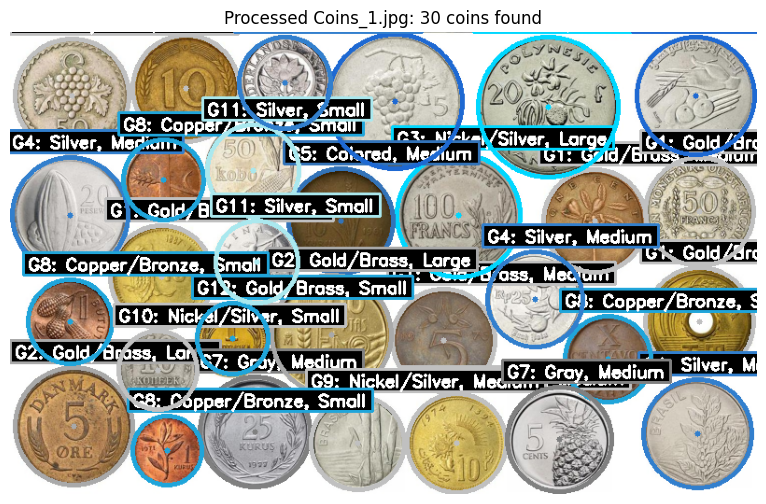

--- Processing: Coins_10.jpg ---
Detected 7 coins in Coins_10.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 7 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 1 coins
      Size: Large
      Color: Silver
      Avg Diameter: 172.0 pixels
      Coin IDs: [1]

 GROUP 2: 1 coins
      Size: Large
      Color: Reddish-Brown
      Avg Diameter: 178.0 pixels
      Coin IDs: [2]

 GROUP 3: 1 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 168.0 pixels
      Coin IDs: [3]

 GROUP 4: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 158.0 pixels
      Coin IDs: [4]

 GROUP 5: 1 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 170.0 pixels
      Coin IDs: [5]

 GROUP 6: 1 coins
      Size: Small
      Color: Gray
      Avg Diameter: 142.0 pixels
      Coin IDs: [6]

 GROUP 7: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 140.0 pixels
 

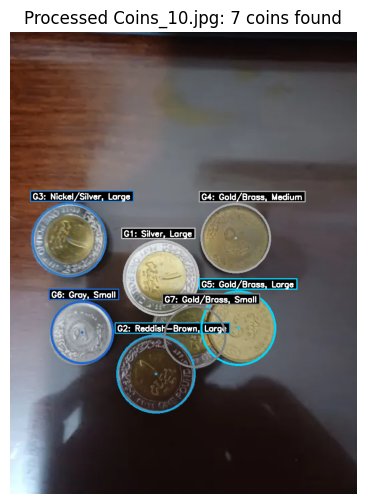

--- Processing: Coins_11.jpg ---
Detected 7 coins in Coins_11.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 7 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 2 coins
      Size: Medium
      Color: Colored
      Avg Diameter: 89.0 pixels
      Coin IDs: [1, 4]

 GROUP 2: 2 coins
      Size: Small
      Color: Colored
      Avg Diameter: 85.0 pixels
      Coin IDs: [2, 7]

 GROUP 3: 1 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 88.0 pixels
      Coin IDs: [3]

 GROUP 4: 1 coins
      Size: Large
      Color: Gray
      Avg Diameter: 92.0 pixels
      Coin IDs: [5]

 GROUP 5: 1 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 94.0 pixels
      Coin IDs: [6]

------------------------------------------------------------

🎨 By Color:
   Colored        :  4 coins (57.1%)
   Gray           :  2 coins (28.6%)
   Nickel/Silver  :  1 coins (14.3%)

📏 By Size:
   Medium      :  3 

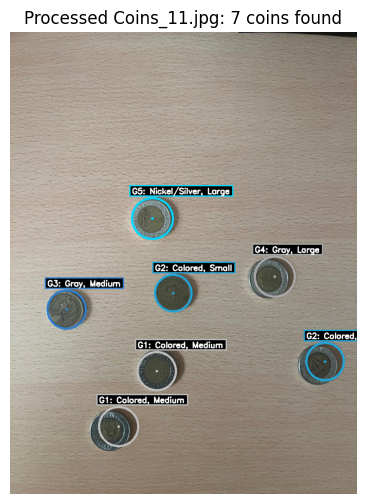

--- Processing: Coins_12.jpg ---
Detected 8 coins in Coins_12.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 8 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 2: 3 coins
      Size: Large
      Color: Colored
      Avg Diameter: 99.3 pixels
      Coin IDs: [2, 4, 7]

 GROUP 1: 2 coins
      Size: Large
      Color: Gray
      Avg Diameter: 90.0 pixels
      Coin IDs: [1, 5]

 GROUP 3: 2 coins
      Size: Medium
      Color: Colored
      Avg Diameter: 84.0 pixels
      Coin IDs: [3, 6]

 GROUP 4: 1 coins
      Size: Small
      Color: Copper/Bronze
      Avg Diameter: 26.0 pixels
      Coin IDs: [8]

------------------------------------------------------------

🎨 By Color:
   Colored        :  5 coins (62.5%)
   Gray           :  2 coins (25.0%)
   Copper/Bronze  :  1 coins (12.5%)

📏 By Size:
   Large       :  5 coins (62.5%)
   Medium      :  2 coins (25.0%)
   Small       :  1 coins (12.5%)

  ✓ Saved 8 cropped

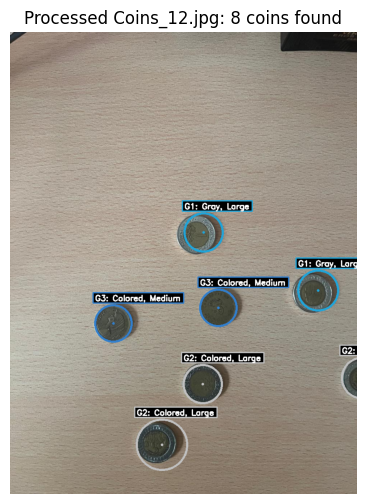

--- Processing: Coins_13.jpg ---
Detected 5 coins in Coins_13.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 5 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 2 coins
      Size: Small
      Color: Colored
      Avg Diameter: 122.0 pixels
      Coin IDs: [1, 4]

 GROUP 3: 2 coins
      Size: Large
      Color: Colored
      Avg Diameter: 140.0 pixels
      Coin IDs: [3, 5]

 GROUP 2: 1 coins
      Size: Medium
      Color: Colored
      Avg Diameter: 130.0 pixels
      Coin IDs: [2]

------------------------------------------------------------

🎨 By Color:
   Colored        :  5 coins (100.0%)

📏 By Size:
   Small       :  2 coins (40.0%)
   Large       :  2 coins (40.0%)
   Medium      :  1 coins (20.0%)

  ✓ Saved 5 cropped coins to output\Coins_13/


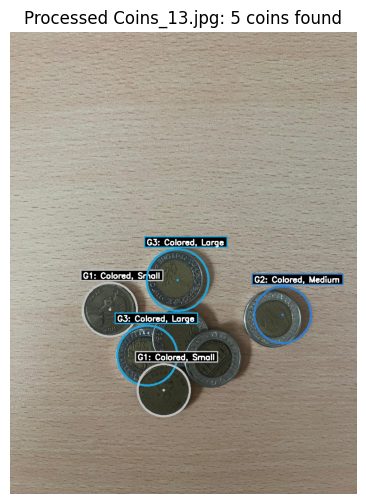

--- Processing: Coins_14.jpg ---
Detected 6 coins in Coins_14.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 6 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 2: 3 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 162.0 pixels
      Coin IDs: [2, 3, 5]

 GROUP 1: 2 coins
      Size: Large
      Color: Colored
      Avg Diameter: 162.0 pixels
      Coin IDs: [1, 6]

 GROUP 3: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 142.0 pixels
      Coin IDs: [4]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  4 coins (66.7%)
   Colored        :  2 coins (33.3%)

📏 By Size:
   Large       :  5 coins (83.3%)
   Small       :  1 coins (16.7%)

  ✓ Saved 6 cropped coins to output\Coins_14/


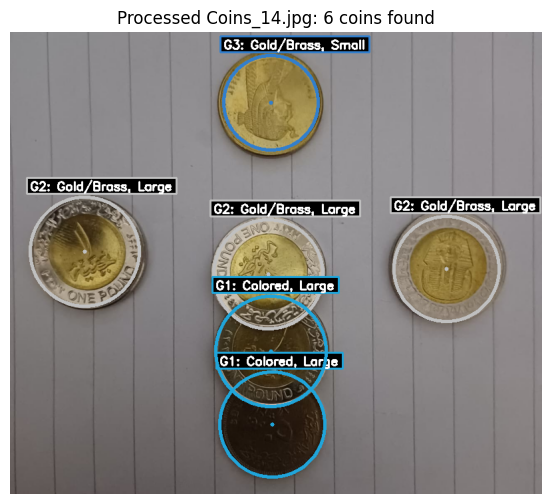

--- Processing: Coins_15.jpg ---
Detected 11 coins in Coins_15.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 11 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 5 coins
      Size: Large
      Color: Gray
      Avg Diameter: 125.6 pixels
      Coin IDs: [1, 2, 3, 4, 6]

 GROUP 2: 3 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 105.3 pixels
      Coin IDs: [5, 7, 9]

 GROUP 3: 3 coins
      Size: Small
      Color: Gray
      Avg Diameter: 92.7 pixels
      Coin IDs: [8, 10, 11]

------------------------------------------------------------

🎨 By Color:
   Gray           : 11 coins (100.0%)

📏 By Size:
   Large       :  5 coins (45.5%)
   Medium      :  3 coins (27.3%)
   Small       :  3 coins (27.3%)

  ✓ Saved 11 cropped coins to output\Coins_15/


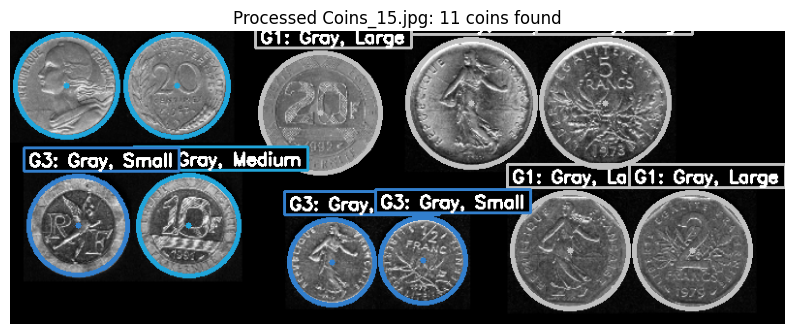

--- Processing: Coins_2.jpg ---
Detected 63 coins in Coins_2.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 63 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 3: 17 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 111.1 pixels
      Coin IDs: [3, 4, 5, 7, 11, 13, 21, 24, 30, 31, 37, 40, 42, 44, 45, 49, 60]

 GROUP 1: 15 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 90.7 pixels
      Coin IDs: [1, 6, 9, 10, 14, 15, 26, 33, 34, 36, 46, 47, 53, 55, 62]

 GROUP 7: 8 coins
      Size: Medium
      Color: Silver
      Avg Diameter: 90.2 pixels
      Coin IDs: [25, 38, 43, 50, 51, 58, 59, 61]

 GROUP 10: 5 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 66.8 pixels
      Coin IDs: [35, 48, 54, 56, 63]

 GROUP 2: 4 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 112.0 pixels
      Coin IDs: [2, 8, 12, 28]

 GROUP 5: 4 coins
      Size: La

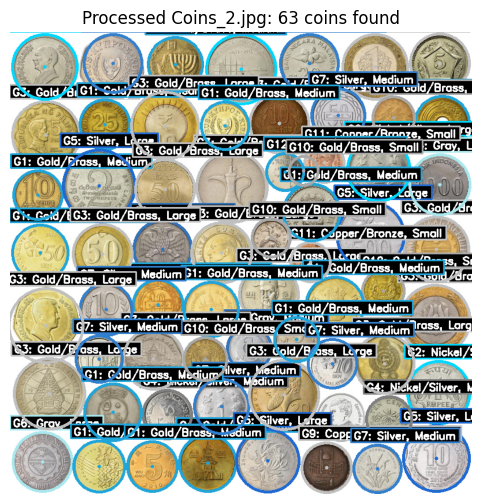

--- Processing: Coins_3.jpg ---
Detected 24 coins in Coins_3.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 24 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 4 coins
      Size: Medium
      Color: Copper/Bronze
      Avg Diameter: 105.0 pixels
      Coin IDs: [1, 8, 15, 24]

 GROUP 3: 4 coins
      Size: Large
      Color: Silver
      Avg Diameter: 127.5 pixels
      Coin IDs: [3, 4, 18, 23]

 GROUP 2: 3 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 131.3 pixels
      Coin IDs: [2, 5, 11]

 GROUP 4: 3 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 95.3 pixels
      Coin IDs: [6, 9, 22]

 GROUP 5: 2 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 112.0 pixels
      Coin IDs: [7, 13]

 GROUP 7: 2 coins
      Size: Medium
      Color: Silver
      Avg Diameter: 111.0 pixels
      Coin IDs: [12, 19]

 GROUP 11: 2 coins
      Size: Small
      Color: Color

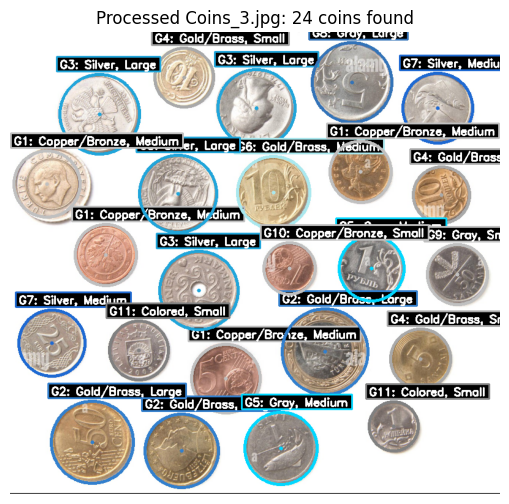

--- Processing: Coins_4.jpg ---
Detected 28 coins in Coins_4.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 28 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 2: 8 coins
      Size: Small
      Color: Copper/Bronze
      Avg Diameter: 115.2 pixels
      Coin IDs: [2, 6, 12, 14, 19, 21, 27, 28]

 GROUP 6: 5 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 136.4 pixels
      Coin IDs: [9, 11, 13, 15, 25]

 GROUP 4: 3 coins
      Size: Medium
      Color: Copper/Bronze
      Avg Diameter: 135.3 pixels
      Coin IDs: [4, 5, 8]

 GROUP 8: 3 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 110.0 pixels
      Coin IDs: [16, 17, 23]

 GROUP 9: 3 coins
      Size: Small
      Color: Gray
      Avg Diameter: 119.3 pixels
      Coin IDs: [18, 22, 26]

 GROUP 1: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 140.0 pixels
      Coin IDs: [1]

 GROUP 3: 1 coins
      Siz

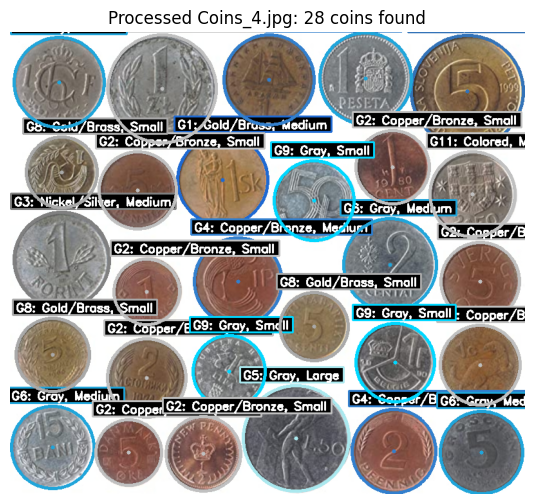

--- Processing: Coins_5.jpg ---
Detected 10 coins in Coins_5.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 10 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 4: 3 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 178.7 pixels
      Coin IDs: [4, 5, 10]

 GROUP 1: 2 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 258.0 pixels
      Coin IDs: [1, 9]

 GROUP 2: 2 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 220.0 pixels
      Coin IDs: [2, 7]

 GROUP 3: 1 coins
      Size: Medium
      Color: Nickel/Silver
      Avg Diameter: 226.0 pixels
      Coin IDs: [3]

 GROUP 5: 1 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 248.0 pixels
      Coin IDs: [6]

 GROUP 6: 1 coins
      Size: Small
      Color: Nickel/Silver
      Avg Diameter: 178.0 pixels
      Coin IDs: [8]

------------------------------------------------------------

🎨 By 

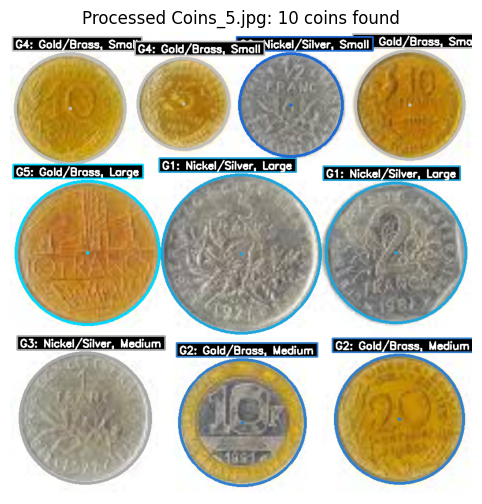

--- Processing: Coins_6.jpg ---
Detected 6 coins in Coins_6.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 6 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 2: 3 coins
      Size: Large
      Color: Silver
      Avg Diameter: 235.3 pixels
      Coin IDs: [2, 3, 5]

 GROUP 1: 1 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 236.0 pixels
      Coin IDs: [1]

 GROUP 3: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 198.0 pixels
      Coin IDs: [4]

 GROUP 4: 1 coins
      Size: Small
      Color: Silver
      Avg Diameter: 74.0 pixels
      Coin IDs: [6]

------------------------------------------------------------

🎨 By Color:
   Silver         :  4 coins (66.7%)
   Gold/Brass     :  2 coins (33.3%)

📏 By Size:
   Large       :  4 coins (66.7%)
   Medium      :  1 coins (16.7%)
   Small       :  1 coins (16.7%)

  ✓ Saved 6 cropped coins to output\Coins_6/


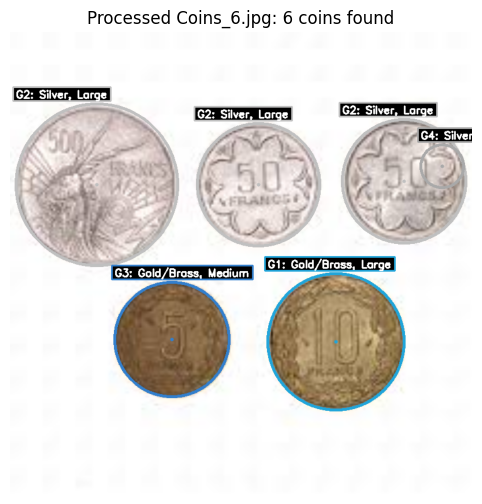

--- Processing: Coins_7.jpg ---
Detected 14 coins in Coins_7.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 14 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 4 coins
      Size: Large
      Color: Silver
      Avg Diameter: 141.0 pixels
      Coin IDs: [1, 2, 3, 9]

 GROUP 3: 4 coins
      Size: Small
      Color: Silver
      Avg Diameter: 86.0 pixels
      Coin IDs: [5, 6, 8, 11]

 GROUP 2: 2 coins
      Size: Medium
      Color: Silver
      Avg Diameter: 104.0 pixels
      Coin IDs: [4, 14]

 GROUP 4: 2 coins
      Size: Small
      Color: Copper/Bronze
      Avg Diameter: 84.0 pixels
      Coin IDs: [7, 13]

 GROUP 5: 2 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 118.0 pixels
      Coin IDs: [10, 12]

------------------------------------------------------------

🎨 By Color:
   Silver         : 10 coins (71.4%)
   Copper/Bronze  :  2 coins (14.3%)
   Gold/Brass     :  2 coins (14.3

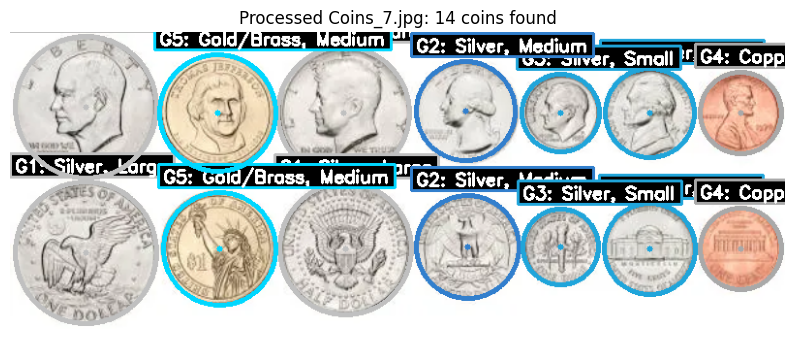

--- Processing: Coins_8.jpg ---
Detected 7 coins in Coins_8.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 7 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 2: 3 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 188.0 pixels
      Coin IDs: [2, 4, 7]

 GROUP 1: 2 coins
      Size: Medium
      Color: Colored
      Avg Diameter: 173.0 pixels
      Coin IDs: [1, 5]

 GROUP 3: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 154.0 pixels
      Coin IDs: [3]

 GROUP 4: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 180.0 pixels
      Coin IDs: [6]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  5 coins (71.4%)
   Colored        :  2 coins (28.6%)

📏 By Size:
   Medium      :  3 coins (42.9%)
   Large       :  3 coins (42.9%)
   Small       :  1 coins (14.3%)

  ✓ Saved 7 cropped coins to output\Coins_8/


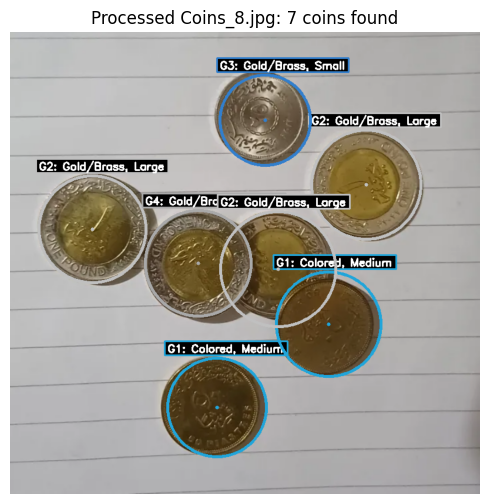

--- Processing: Coins_9.jpg ---
Detected 6 coins in Coins_9.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 6 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 4 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 283.5 pixels
      Coin IDs: [1, 2, 3, 5]

 GROUP 2: 1 coins
      Size: Large
      Color: Colored
      Avg Diameter: 264.0 pixels
      Coin IDs: [4]

 GROUP 3: 1 coins
      Size: Small
      Color: Silver
      Avg Diameter: 52.0 pixels
      Coin IDs: [6]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  4 coins (66.7%)
   Colored        :  1 coins (16.7%)
   Silver         :  1 coins (16.7%)

📏 By Size:
   Large       :  5 coins (83.3%)
   Small       :  1 coins (16.7%)

  ✓ Saved 6 cropped coins to output\Coins_9/


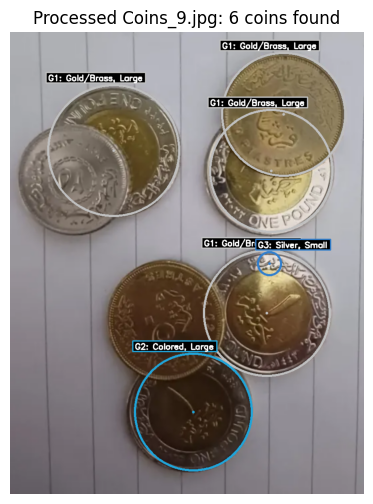

In [262]:
# Section 8 - Automated Folder Processing & Extraction
input_folder = "data"
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

valid_exts = (".jpg", ".jpeg", ".png")
images = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_exts)]

for filename in images:
    path = os.path.join(input_folder, filename)
    print(f"--- Processing: {filename} ---")

    # 1. Detect
    img, circles = detect_coins(path)

    if circles is not None:
        img_name = os.path.splitext(filename)[0]
        img_dir = os.path.join(output_folder, img_name)
        os.makedirs(img_dir, exist_ok=True)

        # 2. Calculate dynamic thresholds for this image
        coin_list = [{'radius': c[2]} for c in circles]
        thresholds = get_dynamic_thresholds(coin_list)

        # 3. Extract Features (Now includes diameter_pixels)
        features = extract_coin_features(img, circles, thresholds)

        # 4. Group (Now includes avg_diameter)
        groups = group_similar_coins(features)

        # 5. Print Summary (Will now find 'avg_diameter')
        print_summary(features, groups)
        stats_img = create_stats_image(features, groups)

        # 6. Enhanced Extraction Loop with better cropping
        for i, coin in enumerate(features):
            x, y = coin['center']
            r = coin['radius']

            # Dynamic padding based on coin size (percentage of radius)
            pad_percentage = 0.15  # 15% padding around the coin
            pad = int(r * pad_percentage)

            # Ensure we don't go outside image boundaries
            y1 = max(0, y - r - pad)
            y2 = min(img.shape[0], y + r + pad)
            x1 = max(0, x - r - pad)
            x2 = min(img.shape[1], x + r + pad)

            # Extract coin with padding
            coin_crop = img[y1:y2, x1:x2]

            # Create a circular mask for cleaner extraction (optional)
            if coin_crop.size > 0:
                # Create a white background for better visibility
                h, w = coin_crop.shape[:2]
                center_crop = (r + pad, r + pad)  # Approximate center in cropped image

                # Save the cropped coin
                filename_coin = f"coin_{i+1}_{coin['color']}_{coin['size']}_r{coin['radius']}px.png"
                cv2.imwrite(os.path.join(img_dir, filename_coin), coin_crop)

                # Also save a masked version (coin with transparent background if needed)
                mask = np.zeros((h, w), dtype=np.uint8)
                cv2.circle(mask, (min(x - x1, w-1), min(y - y1, h-1)), r, 255, -1)

                # Apply mask to make background black
                masked_coin = cv2.bitwise_and(coin_crop, coin_crop, mask=mask)
                masked_filename = f"coin_{i+1}_{coin['color']}_{coin['size']}_masked.png"
                cv2.imwrite(os.path.join(img_dir, masked_filename), masked_coin)

        print(f"  ✓ Saved {len(features)} cropped coins to {img_dir}/")

        # 7. Final Output
        processed_img = annotate_image(img.copy(), features, groups)
        cv2.imwrite(os.path.join(img_dir, "_summary_annotated.jpg"), processed_img)

        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Processed {filename}: {len(features)} coins found")
        plt.axis('off')
        plt.show()
    else:
        print(f"Skipping {filename}: No coins found.")